<a href="https://colab.research.google.com/github/usman-infinity/Final_For_The_Research_Paper-/blob/main/MODEL%3ECNN_BiGRU_WITH_CITY_GRAPHS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving pakistan_air_quality_final_clean.csv to pakistan_air_quality_final_clean.csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN-BiGRU Model...
Epoch 1/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 153s 8ms/step - loss: 0.0012 - mae: 0.0234 - val_loss: 6.5087e-04 - val_mae: 0.0200
Epoch 2/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 143s 8ms/step - loss: 7.9078e-04 - mae: 0.0188 - val_loss: 3.4501e-04 - val_mae: 0.0120
Epoch 3/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 141s 8ms/step - loss: 7.2524e-04 - mae: 0.0180 - val_loss: 4.9973e-04 - val_mae: 0.0159
Epoch 4/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 142s 8ms/step - loss: 6.7396e-04 - mae: 0.0171 - val_loss: 3.9390e-04 - val_mae: 0.0143
Epoch 5/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 143s 8ms/step - loss: 6.4286e-04 - mae: 0.0167 - val_loss: 5.6039e-04 - val_mae: 0.0160
Epoch 6/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 144s 8ms/step - loss: 6.3060e-04 - mae: 0.0165 - val_loss: 3.1998e-04 - val_mae: 0.0113
Epoch 7/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 143s 8ms/step - loss: 6.3561e-04 - mae: 0.0166 - val_loss: 3.8156e-04 - val_mae: 0.0135
Epoch 8/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 143s 8ms

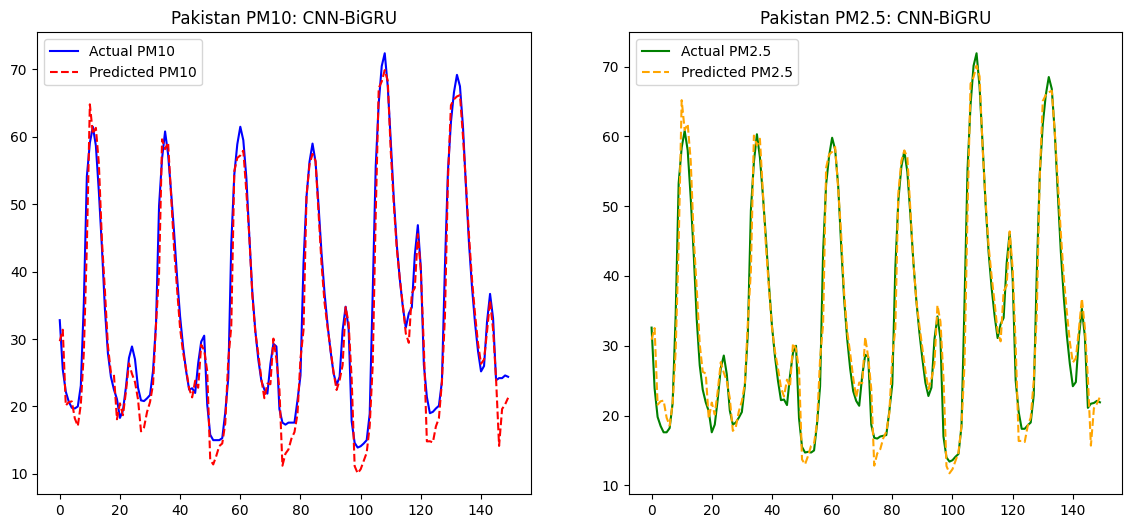

Model saved successfully.
Model loaded successfully.
              City Pollutant    MAE   RMSE      R2
0       Faisalabad      PM10  10.24  14.87  0.9679
1       Faisalabad      PM25  10.02  14.65  0.9686
2        Islamabad      PM10   6.47   8.59  0.9114
3        Islamabad      PM25   4.47   6.48  0.9470
4          Karachi      PM10  22.23  26.69 -0.5879
5          Karachi      PM25   8.21  10.12  0.5450
6           Lahore      PM10   7.32  10.76  0.9705
7           Lahore      PM25   7.10  10.47  0.9721
8           Multan      PM10   9.19  14.10  0.9620
9           Multan      PM25   7.91  12.72  0.9687
10        Peshawar      PM10   5.70   7.68  0.9365
11        Peshawar      PM25   5.01   6.93  0.9466
12          Quetta      PM10  44.66  52.76 -0.1181
13          Quetta      PM25   6.37   7.61  0.5247
14  Rahim Yar Khan      PM10   4.49   6.50  0.9643
15  Rahim Yar Khan      PM25   4.60   6.44  0.9660
16      Rawalpindi      PM10   6.47   8.59  0.9114
17      Rawalpindi      PM25 

In [1]:
# =========================================================
# 🚀 PAKISTAN AIR QUALITY: CNN + BiGRU (LSTM REMOVED)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Sequential

# ----------------------------
# 1️⃣ Load & Clean Dataset
# ----------------------------
try:
    # Update filename as per your specific Pakistan dataset file
    df = pd.read_csv("pakistan_air_quality_final_clean.csv")
except:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

# Clean and format columns
df.rename(columns={'pm2_5': 'pm25', 'PM2.5': 'pm25', 'PM10': 'pm10'}, inplace=True)
df = df[['timestamp', 'pm10', 'pm25']]
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df = df.dropna()

# ----------------------------
# 2️⃣ Normalize Data
# ----------------------------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# ----------------------------
# 3️⃣ Create Sequences (2 Features: PM10 & PM25)
# ----------------------------
def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, :])
    return np.array(X), np.array(y)

time_step = 24
X, y = create_dataset(scaled_data, time_step)

# ----------------------------
# 4️⃣ Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ----------------------------
# 5️⃣ Build CNN-BiGRU Model
# ----------------------------
model = Sequential([
    # CNN Layer for spatial/local feature extraction
    layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                  input_shape=(time_step, 2), padding='same'),
    layers.MaxPooling1D(pool_size=2),

    # BiGRU Layer
    # return_sequences is False because it's the last recurrent layer
    layers.Bidirectional(layers.GRU(64, return_sequences=False)),

    # Output Head
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(2) # Predicting [PM10, PM25]
])

# ----------------------------
# 6️⃣ Compile & Train
# ----------------------------
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training CNN-BiGRU Model...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=1,
    validation_data=(X_test, y_test),
    verbose=1
)

# ----------------------------
# 7️⃣ Predict & Evaluate
# ----------------------------
predictions = model.predict(X_test)
predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

# ----------------------------
# 8️⃣ Visualizing Results
# ----------------------------
plt.figure(figsize=(14, 6))

# Plot PM10
plt.subplot(1, 2, 1)
plt.plot(y_test_inv[:150, 0], label='Actual PM10', color='blue')
plt.plot(predictions_inv[:150, 0], label='Predicted PM10', color='red', linestyle='--')
plt.title("Pakistan PM10: CNN-BiGRU")
plt.legend()

# Plot PM2.5
plt.subplot(1, 2, 2)
plt.plot(y_test_inv[:150, 1], label='Actual PM2.5', color='green')
plt.plot(predictions_inv[:150, 1], label='Predicted PM2.5', color='orange', linestyle='--')
plt.title("Pakistan PM2.5: CNN-BiGRU")
plt.legend()

plt.show()

# ----------------------------
# 9️⃣ Save Model
# ----------------------------
model.save('pakistan_cnn_bigru.h5')
print("Model saved successfully.")

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# --- 1. Load Data ---
df = pd.read_csv("pakistan_air_quality_final_clean.csv")
df.rename(columns={'pm2_5':'pm25'}, inplace=True)

# --- 2. Load Your Model ---
# Note: Ensure you saved your model in your training script using: model.save('my_model.h5')
# For now, I will use the architecture logic to help you get the structure right
try:
    model = tf.keras.models.load_model('pakistan_cnn_bigru.h5', compile=False) # Corrected model name
    print("Model loaded successfully.")
except:
    print("Model file not found. Ensure you save your model first!")
    exit()

def create_windows(data, time_step=24):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), :])
        y.append(data[i+time_step, :])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
city_results = []

# --- 3. Evaluate Each City ---
for city in df['city'].unique():
    city_df = df[df['city'] == city][['pm10', 'pm25']].dropna()

    if len(city_df) < 50: continue # Skip if data is too small

    # Scale data
    scaled_data = scaler.fit_transform(city_df)

    # Create windows for prediction
    X_city, y_city = create_windows(scaled_data)

    # Generate PREDICTIONS
    preds_scaled = model.predict(X_city, verbose=0)

    # Inverse scaling to get real ug/m3 values
    preds = scaler.inverse_transform(preds_scaled)
    actual = scaler.inverse_transform(y_city)

    for i, pollutant in enumerate(['PM10', 'PM25']):
        mae = mean_absolute_error(actual[:, i], preds[:, i])
        rmse = np.sqrt(mean_squared_error(actual[:, i], preds[:, i]))
        r2 = r2_score(actual[:, i], preds[:, i])

        city_results.append({
            'City': city,
            'Pollutant': pollutant,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'R2': round(r2, 4)
        })

# --- 4. Final Output ---
results_df = pd.DataFrame(city_results)
results_df.to_csv("Real_City_Metrics.csv", index=False)
print(results_df)


In [2]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.5 MB/s eta 0:00:00


## 10. Hyperparameter Tuning with KerasTuner

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Sequential

In [ ]:
import numpy as np
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, Sequential

# Time step
time_step = 24


# Create dataset function
def create_dataset(data, time_step=24):
    X, y = [], []

    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, :])

    return np.array(X), np.array(y)


# Build model function for tuner
def build_model(hp, time_step=24):

    model = Sequential([

        layers.Conv1D(
            filters=hp.Int(
                'conv_filters',
                min_value=32,
                max_value=128,
                step=32
            ),
            kernel_size=hp.Choice(
                'kernel_size',
                values=[3, 5]
            ),
            activation='relu',
            input_shape=(time_step, 2),
            padding='same'
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Bidirectional(
            layers.GRU(
                units=hp.Int(
                    'gru_units',
                    min_value=32,
                    max_value=128,
                    step=32
                ),
                return_sequences=False
            )
        ),

        layers.Dropout(0.2),

        layers.Dense(
            units=hp.Int(
                'dense_units',
                min_value=16,
                max_value=64,
                step=16
            ),
            activation='relu'
        ),

        layers.Dense(2)
    ])

    # Tune learning rate
    learning_rate = hp.Choice(
        'learning_rate',
        values=[1e-2, 1e-3, 1e-4]
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model


# Instantiate tuner (FIXED)
tuner = kt.Hyperband(

    lambda hp: build_model(hp, time_step=time_step),

    objective='val_mae',
    max_epochs=30,
    factor=3,

    directory='my_dir',
    project_name='pakistan_air_quality_tuning'
)

print("Starting hyperparameter search...")


# Run search
tuner.search(
    X_train,
    y_train,
    epochs=30,
    batch_size=1,
    validation_data=(X_test, y_test),
    verbose=1
)


# Best hyperparameters
best_hps = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print("\nBest Hyperparameters:")
print("Conv1D filters:", best_hps.get('conv_filters'))
print("Kernel size:", best_hps.get('kernel_size'))
print("GRU units:", best_hps.get('gru_units'))
print("Dense units:", best_hps.get('dense_units'))
print("Learning rate:", best_hps.get('learning_rate'))


# Build best model
best_model = tuner.get_best_models(
    num_models=1
)[0]

print("\nEvaluating best model...")


# Evaluate
loss, mae = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f'Best model test MAE: {mae:.4f}')


# Save model (optional)
# best_model.save('best_tuned_pakistan_cnn_bigru.h5')
# print("Best model saved successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting hyperparameter search...

Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
128               |128               |conv_filters
5                 |5                 |kernel_size
32                |32                |gru_units
32                |32                |dense_units
0.0001            |0.0001            |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 159s 9ms/step - loss: 0.0018 - mae: 0.0260 - val_loss: 3.7869e-04 - val_mae: 0.0130
Epoch 2/2
 7337/17452 ━━━━━━━━━━━━━━━━━━━━ 1:34 9ms/step - loss: 8.7806e-04 - mae: 0.0196

### Predicted vs Actual for Each City

In [ ]:
for city in df['city'].unique():
    city_df = df[df['city'] == city][['pm10', 'pm25']].dropna()

    if len(city_df) < 50: # Skip if data is too small for meaningful prediction
        print(f"Skipping {city}: not enough data.")
        continue

    # Scale data for the current city
    # Re-initialize scaler for each city to avoid data leakage (though often trained once globally)
    local_scaler = MinMaxScaler()
    scaled_data_city = local_scaler.fit_transform(city_df)

    # Create windows for prediction
    X_city, y_city = create_windows(scaled_data_city, time_step=24)

    if len(X_city) == 0:
        print(f"Skipping {city}: not enough data to create sequences.")
        continue

    # Generate PREDICTIONS
    preds_scaled_city = model.predict(X_city, verbose=0)

    # Inverse scaling to get real ug/m3 values
    predictions_inv_city = local_scaler.inverse_transform(preds_scaled_city)
    y_test_inv_city = local_scaler.inverse_transform(y_city)

    # Visualizing Results for the current city
    plt.figure(figsize=(14, 6))
    plt.suptitle(f"Air Quality Prediction for {city}: CNN-BiGRU", fontsize=16)

    # Plot PM10
    plt.subplot(1, 2, 1)
    plt.plot(y_test_inv_city[:, 0], label='Actual PM10', color='blue')
    plt.plot(predictions_inv_city[:, 0], label='Predicted PM10', color='red', linestyle='--')
    plt.title("PM10")
    plt.legend()
    plt.xlabel('Time Step')
    plt.ylabel('PM10 (ug/m3)')

    # Plot PM2.5
    plt.subplot(1, 2, 2)
    plt.plot(y_test_inv_city[:, 1], label='Actual PM2.5', color='green')
    plt.plot(predictions_inv_city[:, 1], label='Predicted PM2.5', color='orange', linestyle='--')
    plt.title("PM2.5")
    plt.legend()
    plt.xlabel('Time Step')
    plt.ylabel('PM2.5 (ug/m3)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

### Variable Statistics by City

In [ ]:
import pandas as pd
from google.colab import files

# Load the dataset specifically for statistics, ensuring 'city' column is present
try:
    df_stats = pd.read_csv("pakistan_air_quality_final_clean.csv")
except FileNotFoundError:
    print("Could not find 'pakistan_air_quality_final_clean.csv' locally. Attempting upload...")
    uploaded = files.upload()
    if uploaded:
        df_stats = pd.read_csv(list(uploaded.keys())[0])
    else:
        print("No file uploaded. Cannot proceed with city-wise statistics.")
        # Optionally raise an error or exit here if df_stats is critical
        raise FileNotFoundError("Dataset file not found or uploaded.")
except Exception as e:
    print(f"An error occurred during file loading: {e}")
    raise

# Rename columns for consistency if necessary, after ensuring df_stats is loaded
df_stats.rename(columns={'pm2_5': 'pm25', 'PM2.5': 'pm25', 'PM10': 'pm10'}, inplace=True)

print('--- PM10 Statistics by City ---')
display(df_stats.groupby('city')['pm10'].describe())

print('\n--- PM2.5 Statistics by City ---')
display(df_stats.groupby('city')['pm25'].describe())